## *Student Final Grade Prediction*

This project predicts stuntss' final grade (`G3`) using demographic, behavioral, and academic features. Two models are compared: an ear_y-year model without previous grades and a m_d-year model including previous grades.

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("C:/Project/Std_performance_project/Data/student_data.csv",sep=";")

### **Problem Statement**

The goal of this project is to predict students' final grade (`G3`) and understand which factors contribute most to student performance.

Two prediction scenarios are considered:

1. Early-Year Model: predicts `G3` without using `G1` and `G2`.
2. Mid-Year Model: predicts `G3` using all available features, including `G1` and `G2`.

This comparison helps understand whether demographic and behavioral factors alone are enough, or whether previous academic performance is necessary for accurate prediction.

In [9]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
df.shape

(395, 33)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [12]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [13]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [14]:
for col in df.select_dtypes(include="object").columns: 
    print(col, df[col].unique())

school ['GP' 'MS']
sex ['F' 'M']
address ['U' 'R']
famsize ['GT3' 'LE3']
Pstatus ['A' 'T']
Mjob ['at_home' 'health' 'other' 'services' 'teacher']
Fjob ['teacher' 'other' 'services' 'health' 'at_home']
reason ['course' 'other' 'home' 'reputation']
guardian ['mother' 'father' 'other']
schoolsup ['yes' 'no']
famsup ['no' 'yes']
paid ['no' 'yes']
activities ['no' 'yes']
nursery ['yes' 'no']
higher ['yes' 'no']
internet ['no' 'yes']
romantic ['no' 'yes']


## Dataset Overview

The dataset contains student demographic, social, academic, and lifestyle-related information. The target variable is `G3`, which represents the final grade.

Important variables include:

- `G1`: first period grade
- `G2`: second period grade
- `G3`: final grade
- `studytime`: weekly study time
- `failures`: number of previous class failures
- `absences`: number of school absences
- `Medu`: mother's education level
- `Fedu`: father's education level
- `Dalc`: weekday alcohol consumption
- `Walc`: weekend alcohol consumption

In [15]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [18]:
df['G3'].value_counts()

##helps to understand the distribution of target variable.
##Your target values are not evenly distributed.

#Example:

#10 → 56 samples
#20 → 1 sample

#This is called imbalanced data.

#Machine learning models may become biased toward frequent classes
#Rare classes may be predicted poorly

##Detect unusual or suspicious values ex, score 25 appears for 5 students but our score range is only from 0-20


G3
10    56
11    47
0     38
15    33
8     32
13    31
12    31
9     28
14    27
16    16
6     15
18    12
7      9
5      7
17     6
19     5
20     1
4      1
Name: count, dtype: int64

## Explanatory Data Analysis


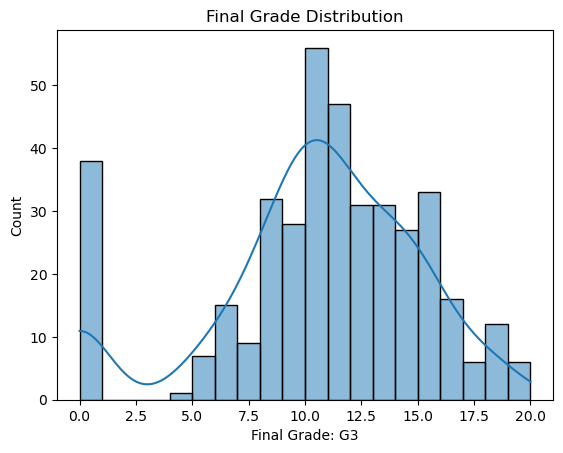

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.xlabel("Final Grade: G3")
plt.ylabel("Count")
plt.title("Final Grade Distribution")
sns.histplot(df["G3"],bins=20,kde=1)
plt.show()
# appears to be a -ve skewed distribution as tail towards the left and more data points on the right side.
#This indicates that a larger proportion of students achieved higher scores while relatively few scored very low marks.

Text(0.5, 1.0, 'Absences v/s Final Grades')

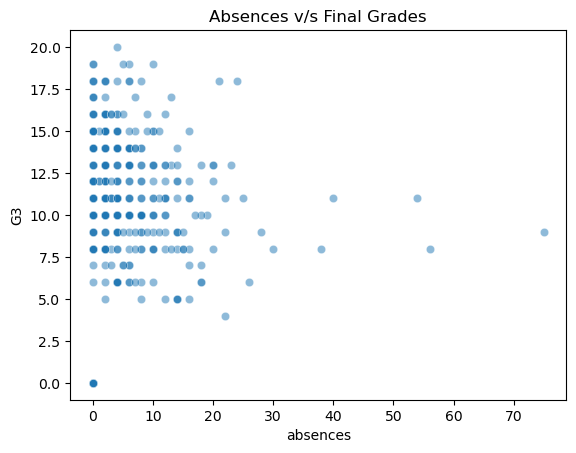

In [20]:
# Now lets try to find if there's any relation between the absence of students and their grades

sns.scatterplot(x="absences",y="G3", data = df, alpha=0.5)
plt.title("Absences v/s Final Grades")


#students with fewer absences seem to include many average-to-excellent marks, but the relationship does not look very strong.

In [21]:
print(df[['absences', 'G3']].corr())

          absences        G3
absences  1.000000  0.034247
G3        0.034247  1.000000


In [22]:
## no strong relationship between absences and final grade.

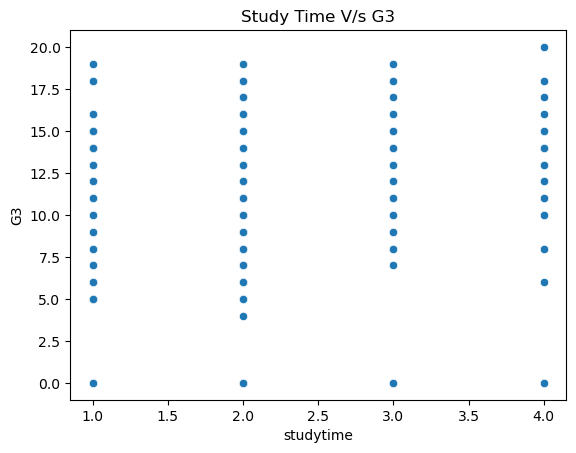

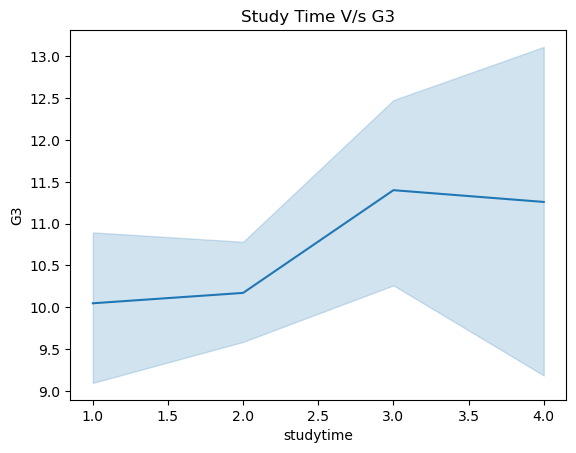

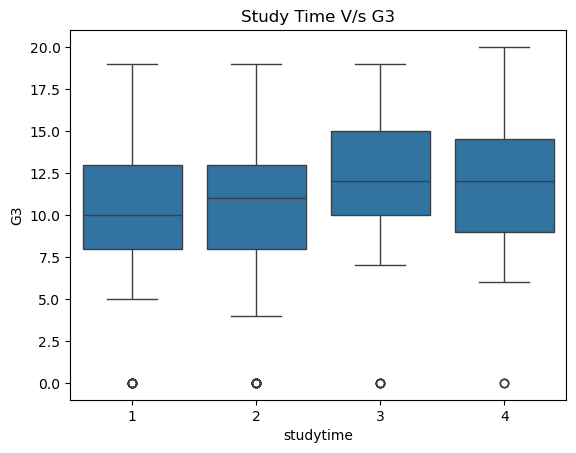

In [23]:
sns.scatterplot(x="studytime",y="G3",data=df)
plt.title("Study Time V/s G3")

plt.show()

sns.lineplot(x="studytime",y="G3",data=df)
plt.title("Study Time V/s G3")

plt.show()


sns.boxplot(x="studytime",y="G3",data=df)
plt.title("Study Time V/s G3")
plt.show()


In [24]:
print(df[['studytime', 'G3']].corr())

           studytime       G3
studytime    1.00000  0.09782
G3           0.09782  1.00000


Positive correlation which means when study time increases grades also increases gradually.
But in the graph its visible that after a purticular point (3) the graph or the plot a slight decrease which can be interpretted as a result of burnout...

In [25]:
df.groupby("studytime")["G3"].mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

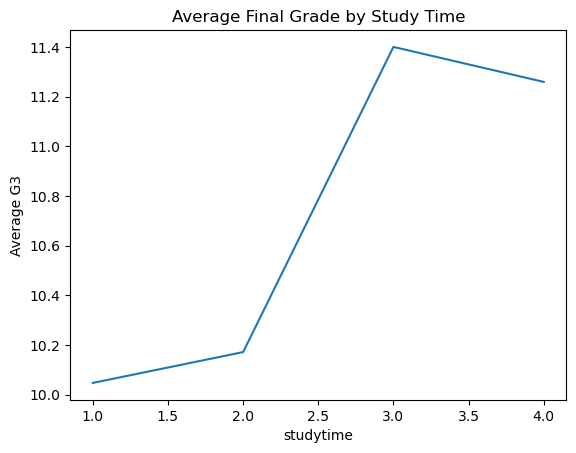

In [26]:
df.groupby('studytime')['G3'].mean().plot(kind='line')
plt.title("Average Final Grade by Study Time")
plt.ylabel("Average G3")
plt.show()

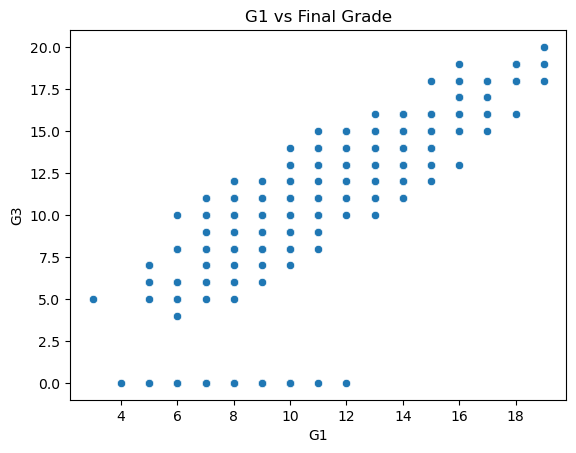

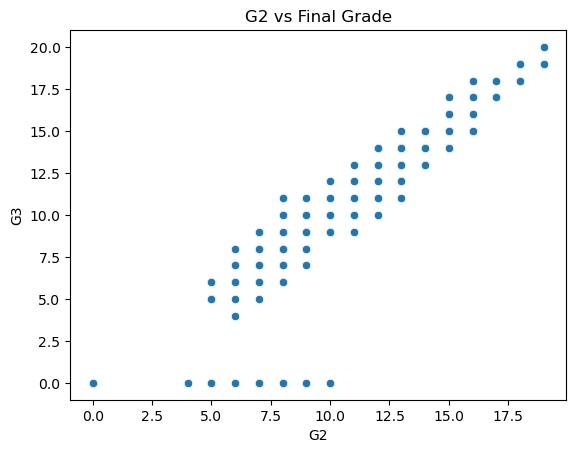

In [27]:
sns.scatterplot(x="G1", y="G3", data =df)
plt.title("G1 vs Final Grade")
plt.show()

sns.scatterplot(x="G2", y="G3", data =df)
plt.title("G2 vs Final Grade")
plt.show()

In [28]:
print(df[['G1', 'G3']].corr())
print(df[['G2', 'G3']].corr())

          G1        G3
G1  1.000000  0.801468
G3  0.801468  1.000000
          G2        G3
G2  1.000000  0.904868
G3  0.904868  1.000000


strong positive correlation

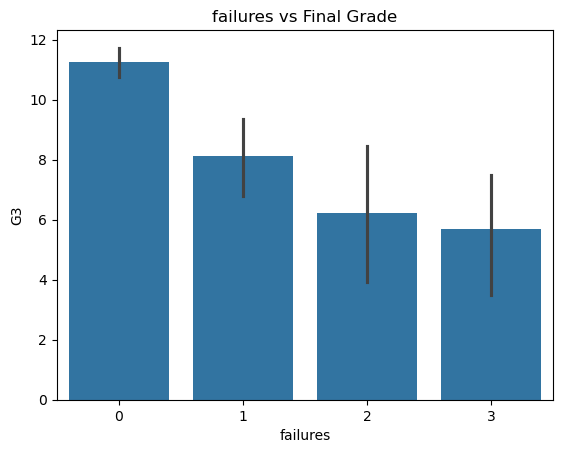

In [29]:
sns.barplot(x="failures", y="G3", data =df)
plt.title("failures vs Final Grade")
plt.show()

In [30]:
print(df[["failures","G3"]].corr())

          failures        G3
failures  1.000000 -0.360415
G3       -0.360415  1.000000


Less failures more final scores!!!
Negatively correlated

Text(0.5, 1.0, 'Internet usage V/s G3 grades')

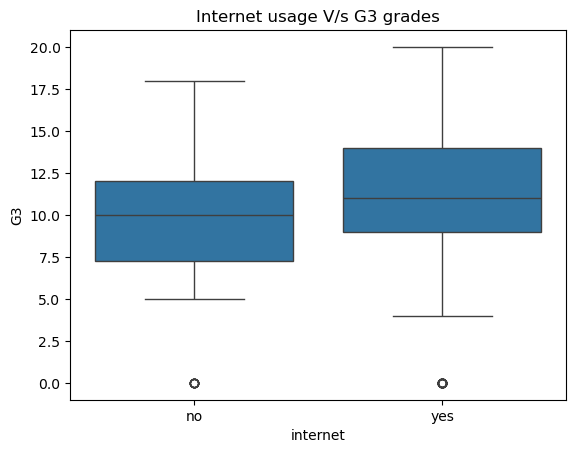

In [31]:
sns.boxplot(x="internet",y="G3",data=df)
plt.title("Internet usage V/s G3 grades")

## EDA Summary

The final grade distribution shows that many students scored around the average-to-good range, while fewer students received very low or very high marks.

The scatterplot between absences and final grade did not show a strong relationship. Similarly, study time showed only a weak relationship with final grade. Previous failures appeared to have a clearer negative relationship with final performance.

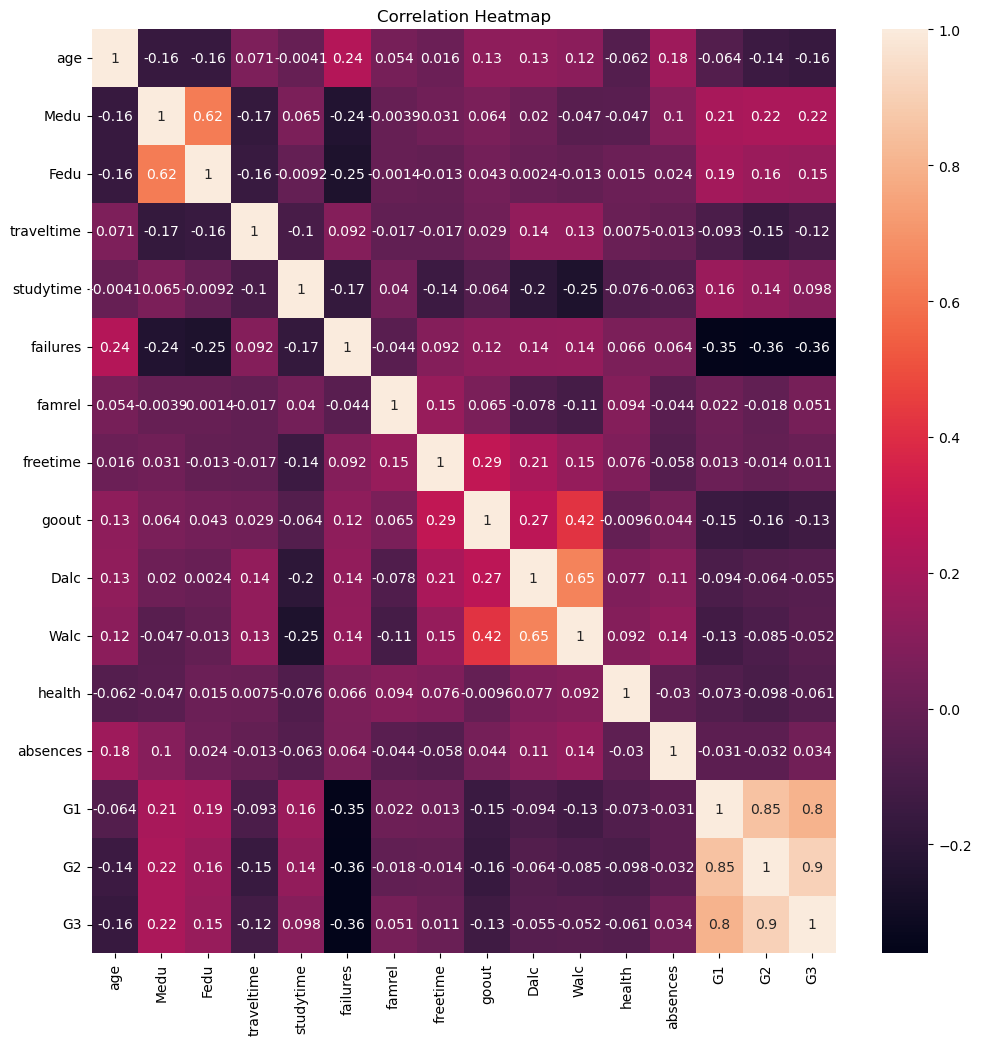

In [32]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True),annot = True)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlation Analysis

The correlation heatmap shows that `G1` and `G2` have the strongest positive correlation with `G3`.

- `G1` and `G3`: strong positive relationship
- `G2` and `G3`: very strong positive relationship
- `failures` and `G3`: moderate negative relationship
- `studytime`, `absences`, and most demographic variables: weak relationship with `G3`

This suggests that previous academic performance is likely to be a much stronger predictor of final grade than demographic or behavioral features alone.

## Modeling Approach

This project uses supervised machine learning because the target variable `G3` is already known in the dataset.

Since `G3` is a numeric value, this is a regression problem.

Two modeling approaches are used:

1. Early-Year Model:
   - Uses all features except `G1`, `G2`, and `G3`.
   - Simulates prediction before previous term grades are available.

2. Mid-Year Model:
   - Uses all features except `G3`.
   - Includes `G1` and `G2`.
   - Simulates prediction after previous term grades are available.

The models are evaluated using MAE, RMSE, and R2 score.

In [33]:
#Import ML Tools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [34]:
# Creating Targets and Feature Sets

y = df["G3"]
X_early = df.drop(columns = ["G1","G2","G3"])
X_mid = df.drop(columns =["G3"])

In [35]:
#Split Data into Tain and Test

#Model 1
X_train_early,X_test_early,y_train,y_test = train_test_split(X_early,y,test_size = 0.2, random_state= 42) 

#Model 2
X_train_mid,X_test_mid,_,_ = train_test_split(X_mid,y,test_size = 0.2, random_state= 42) 

In [36]:
# Preprocessing Function 

def create_preprocessor(X): 
    numeric_columns = X.select_dtypes(include = ["int64","float64"] ).columns
    categorical_columns = X.select_dtypes(include = ["object"] ).columns
    preprocessor = ColumnTransformer(
        transformers = [("num", StandardScaler(),numeric_columns), ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)]
    )
    return preprocessor

In [37]:
# function evaluation

def evaluate_model(model,X_train,X_test,y_train,y_test,model_name):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    mae =mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)
    print(model_name )
    print("MAE:",round(mae,2) )
    print("RMSE:",round(rmse,2) )
    print("R2:",round(r2,2) )
    print("-"*40)

## Evaluation Metrics

MAE, RMSE, and R2 score are used to evaluate the models.

- MAE measures the average prediction error in grade points.
- RMSE also measures prediction error, but gives more penalty to larger mistakes.
- R2 score shows how much variation in `G3` is explained by the model.

Lower MAE and RMSE are better. Higher R2 score is better.

In [38]:
print("Target variable shape:", y.shape)

print("Early-year feature shape:", X_early.shape)
print("Mid model feature shape:", X_mid.shape)

print("Early train shape:", X_train_early.shape)
print("Early test shape:", X_test_early.shape)

print("Mid train shape:", X_train_mid.shape)
print("Mid test shape:", X_test_mid.shape)

Target variable shape: (395,)
Early-year feature shape: (395, 30)
Mid model feature shape: (395, 32)
Early train shape: (316, 30)
Early test shape: (79, 30)
Mid train shape: (316, 32)
Mid test shape: (79, 32)


In [39]:
#Builing Model 1 [Early Year Model]

## create preprocessing tool for model 1

early_preprocessor = create_preprocessor(X_early)

early_baseline_model = Pipeline(steps = [
    ("preprocessor", early_preprocessor),
    ("model", DummyRegressor(strategy = "mean"))
])

early_linear_model =  Pipeline(steps = [
    ("preprocessor", early_preprocessor),
    ("model", LinearRegression())
])

early_rf_model =  Pipeline(steps = [
    ("preprocessor", early_preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])


## evaluating model 1

evaluate_model (early_baseline_model,X_train_early,X_test_early,y_train,y_test,"Early_Year Baseline Model")

evaluate_model (early_linear_model,X_train_early,X_test_early,y_train,y_test,"Early_Year Linear Model")

evaluate_model (early_rf_model,X_train_early,X_test_early,y_train,y_test,"Early_Year RF Model")

Early_Year Baseline Model
MAE: 3.65
RMSE: 4.55
R2: -0.01
----------------------------------------
Early_Year Linear Model
MAE: 3.39
RMSE: 4.19
R2: 0.14
----------------------------------------
Early_Year RF Model
MAE: 3.0
RMSE: 3.77
R2: 0.31
----------------------------------------


*Early-year demographic, behavioral, and school-related features contain some useful signal, but they are not enough for highly accurate prediction.*

In [40]:
#Builing Model 2 [Mid Year Model]


## create preprocessing tool for model 2

mid_preprocessor = create_preprocessor(X_mid)

mid_baseline_model = Pipeline(steps = [
    ("preprocessor", mid_preprocessor),
    ("model", DummyRegressor(strategy = "mean"))
])

mid_linear_model =  Pipeline(steps = [
    ("preprocessor", mid_preprocessor),
    ("model", LinearRegression())
])

mid_rf_model =  Pipeline(steps = [
    ("preprocessor", mid_preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])


## evaluating model 1

evaluate_model (mid_baseline_model,X_train_mid,X_test_mid,y_train,y_test,"Mid_Year Baseline Model")

evaluate_model (mid_linear_model,X_train_mid,X_test_mid,y_train,y_test,"Mid_Year Linear Model")

evaluate_model (mid_rf_model,X_train_mid,X_test_mid,y_train,y_test,"Mid_Year RF Model")

Mid_Year Baseline Model
MAE: 3.65
RMSE: 4.55
R2: -0.01
----------------------------------------
Mid_Year Linear Model
MAE: 1.65
RMSE: 2.38
R2: 0.72
----------------------------------------
Mid_Year RF Model
MAE: 1.21
RMSE: 2.01
R2: 0.8
----------------------------------------


*The mid-year models performed much better than the early-year models. The Random Forest model improved from an R2 score of 0.31 in the early-year model to 0.80 in the mid-year model. The MAE also decreased from 3.00 to 1.21. This shows that including G1 and G2 greatly improves prediction accuracy. Therefore, previous academic performance is the strongest predictor of final grade.*

In [41]:
#Model comparison Table
    

model_results = pd.DataFrame({
    "Model": [
        "Early-Year Baseline",
        "Early-Year Linear Regression",
        "Early-Year Random Forest",
        "Mid-Year Baseline",
        "Mid-Year Linear Regression",
        "Mid-Year Random Forest"
    ],
    "MAE": [3.65, 3.39, 3.00, 3.65, 1.65, 1.21],
    "RMSE": [4.55, 4.19, 3.77, 4.55, 2.38, 2.01],
    "R2 Score": [-0.01, 0.14, 0.31, -0.01, 0.72, 0.80]
})

model_results


,Model,MAE,RMSE,R2 Score
0,Early-Year Baseline,3.65,4.55,-0.01
1,Early-Year Linear Regression,3.39,4.19,0.14
2,Early-Year Random Forest,3.00,3.77,0.31
3,Mid-Year Baseline,3.65,4.55,-0.01
4,Mid-Year Linear Regression,1.65,2.38,0.72
5,Mid-Year Random Forest,1.21,2.01,0.80


## Model Results Interpretation

The early-year models had limited predictive performance. The best early-year model was Random Forest, with an MAE of 3.00 and an R2 score of 0.31. This shows that demographic, social, and behavioral features provide some useful information, but they are not enough for highly accurate grade prediction.

The mid-year models performed much better. The Mid-Year Random Forest model achieved an MAE of 1.21 and an R2 score of 0.80. This shows that including `G1` and `G2` greatly improves prediction accuracy.

Overall, previous academic performance is the strongest predictor of final grade.

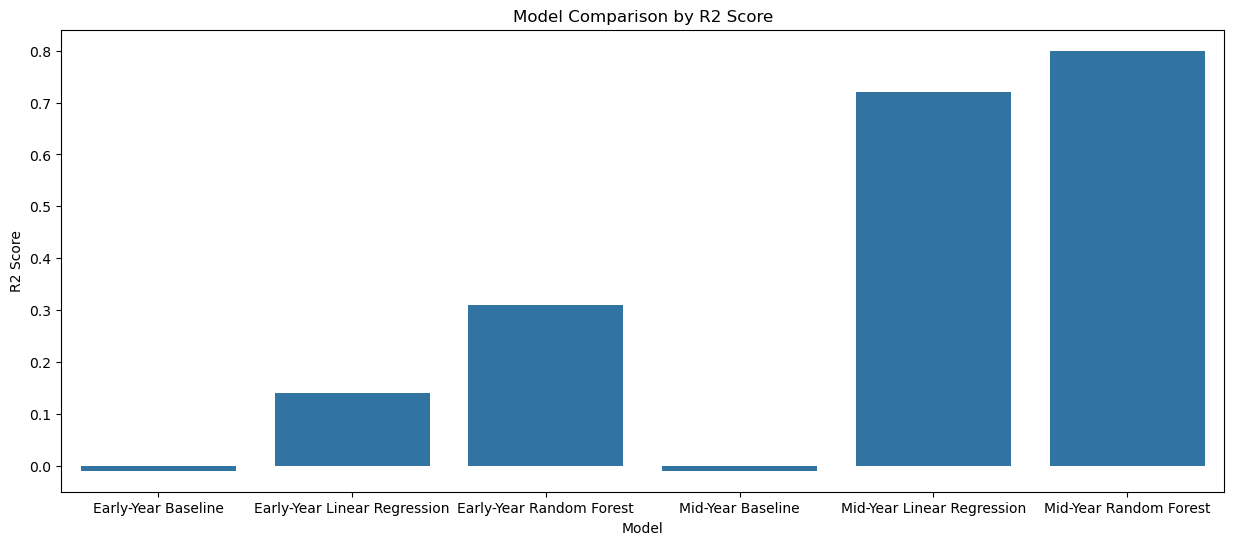

In [42]:
# Model Comparison by barcharts

plt.figure(figsize=(15, 6))
sns.barplot(x="Model", y="R2 Score", data=model_results)
plt.xticks(rotation=0)
plt.title("Model Comparison by R2 Score")
plt.show()

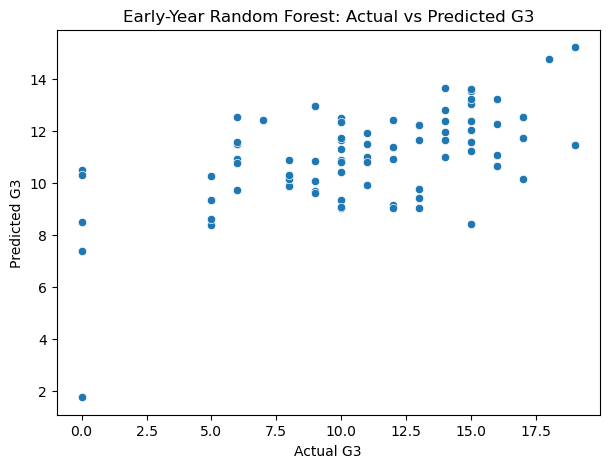

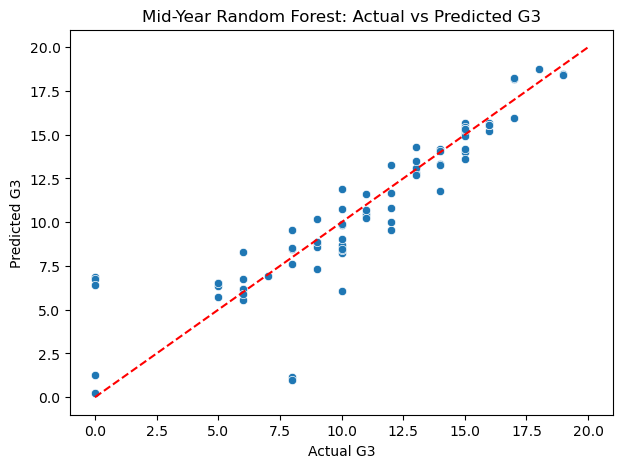

In [43]:
early_rf_predictions = early_rf_model.predict(X_test_early)
mid_rf_predictions = mid_rf_model.predict(X_test_mid)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=early_rf_predictions)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Early-Year Random Forest: Actual vs Predicted G3")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=mid_rf_predictions)
plt.plot([0, 20], [0, 20], color="red", linestyle="--")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Mid-Year Random Forest: Actual vs Predicted G3")
plt.show()

The mid-year model predictions are closer to the red reference line, meaning they are closer to the actual values. This confirms that the mid-year model performs better than the early-year model.

**At Risk Student Identification**

 If G3<10, the student is considered in a risk stage 

In [44]:
risk_results = pd.DataFrame({
    "Actual_G3": y_test,
    "Predicted_G3": mid_rf_predictions
})

risk_results["Risk_Status"] = risk_results["Predicted_G3"].apply(
    lambda score: "At Risk" if score < 10 else "Not At Risk"
)

risk_results.head()

risk_results["Risk_Status"].value_counts()

Risk_Status
Not At Risk    43
At Risk        36
Name: count, dtype: int64

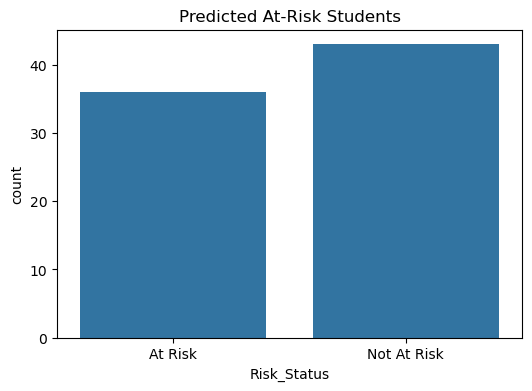

In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Risk_Status", data=risk_results)
plt.title("Predicted At-Risk Students")
plt.show()

Students with predicted `G3` below 10 were classified as "At Risk", since 10 is commonly considered the passing threshold. This risk flag can help identify students who may need academic support.

However, this should be used only as a support tool and not as a final judgment about a student.

**Feature Importance**  - Feature importance tells us which columns the Random Forest used most.

In [46]:
preprocessor = mid_rf_model.named_steps["preprocessor"]
model = mid_rf_model.named_steps["model"]

numeric_features = X_mid.select_dtypes(include=["number"]).columns

categorical_features = preprocessor.named_transformers_["cat"].get_feature_names_out(
    X_mid.select_dtypes(include=["object"]).columns
)

all_features = list(numeric_features) + list(categorical_features)

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
14,G2,0.792268
12,absences,0.109791
36,reason_home,0.019529
0,age,0.010111
13,G1,0.006149
6,famrel,0.004639
8,goout,0.003959
35,reason_course,0.003772
11,health,0.003525
4,studytime,0.003310


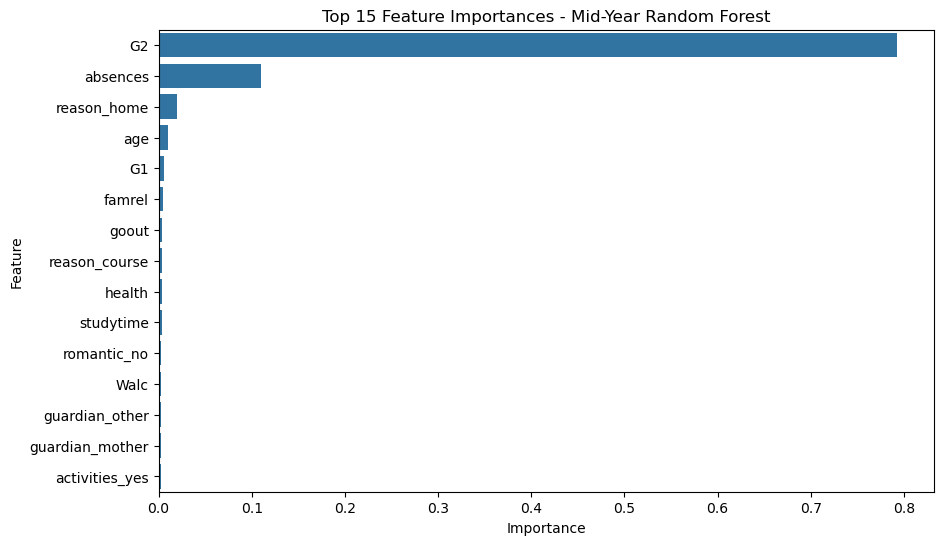

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Feature Importances - Mid-Year Random Forest")
plt.show()

The feature importance results show which variables contributed most to the Random Forest model. `G1` and `G2` are expected to be among the most important features, confirming that previous academic performance is the strongest predictor of final grade.

## Conclusion

This project compared two regression approaches for predicting students' final grade `G3`.

The early-year model used demographic, social, and behavioral features without `G1` and `G2`. Its performance was limited, with the best early-year model achieving an R2 score of 0.31 and an MAE of 3.00.

The mid-year model included all available features, including `G1` and `G2`. This model performed much better, with the best model achieving an R2 score of 0.80 and an MAE of 1.21.

Overall, previous academic performance was the strongest predictor of final grade. Early-year features can provide some useful information, but predictions become much more reliable once previous grades are available.

## Limitations

The dataset is relatively small, so the results may not generalize to all students. Also, the model shows patterns in the data but does not prove that one factor directly causes another. The predictions should be used as a support tool, not as a final judgment about a student.

## Future Work

Future improvements could include cross-validation, hyperparameter tuning, feature selection, and testing the model on a larger dataset.